## Draw the Starfield

In [105]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:70% !important; }</style>"))

### Character Set Diagrams for Star Offsets

In [106]:
import re
from colors_map import *

def loadMonochromeCharacterSet(charset_lines, ref_offset=0):
    character_set = {}
    charset_data = []
    char_ref = None
    for l in charset_lines:
        if "CHARACTER" in l:
            if charset_data:
                character_set[char_ref] = charset_data
            charset_data = []
            ref = int(l[61:63],16) + ref_offset
            char_ref = f"{ref:0{2}x}".upper()
             
        m = re.findall(r"[0-1]{8}",l)
        if not m:
            continue
        bits = m[0].strip()
        line_bits = []
        for i in range(0,8):
            bitpair = bits[i]
            line_bits += [bitpair]
        charset_data += [line_bits]
    character_set[char_ref] = charset_data
    return character_set

charsets_file = "uridium/src/charset.asm"
input_file = open(charsets_file,'r')
charset_lines = input_file.readlines()
charset_lines = charset_lines[1439:]
base_character_set = loadMonochromeCharacterSet(charset_lines)

character_files = [
    "uridium/src/surface1_charset.asm",
    "uridium/src/surface2_charset.asm",
    "uridium/src/surface3_charset.asm",
]
character_sets = []
for filename in character_files:
    charsets_file = filename
    input_file = open(charsets_file,'r')
    charset_lines = input_file.readlines()
    character_set = base_character_set | loadMonochromeCharacterSet(charset_lines, ref_offset=0x80)
    character_sets += [character_set]

resize = lambda img,factor: img.resize((int(img.width * factor), int(img.height * factor)), Image.NEAREST)


In [107]:
from colors_map import *
raw_level_color_schemes = """
        .BYTE M_GRAY1,M_GRAY3,M_ORANGE,M_YELLOW,M_ORANGE  ; Level 1
        .BYTE M_BLACK,M_GRAY1,M_LTBLUE,M_LTRED,M_RED      ; Level 2, Level 13
        .BYTE M_BROWN,M_ORANGE,M_ORANGE,M_LTGREEN,M_GREEN ; Level 3, Level 11
        .BYTE M_GRAY1,M_GRAY3,M_ORANGE,M_LTBLUE,M_BLUE    ; Level 4
        .BYTE M_GREEN,M_LTGREEN,M_ORANGE,M_LTBLUE,M_BLUE  ; Level 5
        .BYTE M_ORANGE,M_YELLOW,M_ORANGE,M_GRAY2,M_BLACK  ; Level 6
        .BYTE M_GRAY1,M_CYAN,M_LTGREEN,M_LTRED,M_RED      ; Level 7
        .BYTE M_BLACK,M_GRAY2,M_LTRED,M_LTBLUE,M_BLUE     ; Level 8
        .BYTE M_BLUE,M_LTBLUE,M_ORANGE,M_LTGREEN,M_GREEN  ; Level 9 , Level 14
        .BYTE M_GRAY1,M_GRAY2,M_GRAY2,M_LTRED,M_RED       ; Level 10
        .BYTE M_BROWN,M_ORANGE,M_ORANGE,M_LTGREEN,M_GREEN ; Level 3, Level 11
        .BYTE M_BLUE,M_CYAN,M_ORANGE,M_GRAY2,M_GRAY1      ; Level 12
        .BYTE M_BLACK,M_GRAY1,M_LTBLUE,M_LTRED,M_RED      ; Level 2, Level 13
        .BYTE M_BLUE,M_LTBLUE,M_ORANGE,M_LTGREEN,M_GREEN  ; Level 9 , Level 14
        .BYTE M_RED,M_LTRED,M_ORANGE,M_YELLOW,M_ORANGE    ; Level 15
"""
raw_level_color_schemes = [l[14:57].split(',') for l in raw_level_color_schemes.split('\n')][1:-1]
raw_level_color_schemes = [[x.strip() for x in l] for l in raw_level_color_schemes]
#raw_level_color_schemes = [v for l in raw_level_color_schemes for v in l]
#surface_ram = [temp_surface_ram[v:v+80] for v in range(0, len(temp_surface_ram), 80)]
#surface_ram = ["$"+x.upper() for x in flatten(surface_ram)]
level_colors = [None]
for l in raw_level_color_schemes:
    colors = (color_constants[l[1]], "c64_black", color_constants[l[0]], "c64_white")
    level_colors += [colors]

# The character sets each level uses.
level_charsets = [0,2,0,2,0,1,2,1,0,1,2,0,2,1,0,2]

level_names = [None, "Zinc","Lead","Copper","Silver","Iron","Gold","Platinum","Tungsten","Iridon","Kallisto","Tri-alloy","Quadmium","Ergonite","Galactium","Uridium"]

In [108]:
from PIL import Image, ImageColor
CHARACTER_COLS = 8
CHARACTER_ROWS = 8
CELL_WIDTH = 40
CELL_HEIGHT = 40

def paintCharacterDiagram(bit_array, colors, verticalExpand=False):
    multicol0, multicol1,color,color1 = colors
    colormap = {
        "01": multicol0,
        "10": color,
        "11": multicol1,
        "00": color1,
    }
    
    image_width = CELL_WIDTH*CHARACTER_COLS
    image_height = CELL_HEIGHT*CHARACTER_ROWS
    img = Image.new( 'RGBA', (image_width+1, image_height+1))
    draw = ImageDraw.Draw(img)

    fnt = ImageFont.truetype("RobotoMono-Light.ttf", 40)
    # Remember that each bitpair in the bit_array is duplicated.
    # e.g. 01 appears as 01,01 so that we can treat each element as
    # a single bit.
    for y, l in enumerate(bit_array):
        for x,bit in enumerate(l):
            color_name = colormap[bit]
            pixel_color = ImageColor.getrgb(c64_to_rgb[color_name])
            X = x * CELL_WIDTH
            Y = y * CELL_HEIGHT
            draw.rectangle((X, Y, X+CELL_WIDTH, Y+CELL_HEIGHT), 
                           fill=pixel_color, outline="black")
            b = bit[(x%2)] # Get the correct side of the bitpair
            text_color = "black" if color_name in ["c64_white","c64_yellow","c64_cyan","c64_ltgreen"] else "white"
            draw.text((X+10, Y-8), b, font=fnt, fill=text_color)
    return img

def paintMonochromeCharacterDiagram(bit_array):
    colormap = {
        "0": "c64_white",
        "1": "c64_black",
    }
    
    image_width = CELL_WIDTH*CHARACTER_COLS
    image_height = CELL_HEIGHT*CHARACTER_ROWS
    img = Image.new( 'RGBA', (image_width+1, image_height+1))
    draw = ImageDraw.Draw(img)

    fnt = ImageFont.truetype("RobotoMono-Light.ttf", 40)
    for y, l in enumerate(bit_array):
        for x,bit in enumerate(l):
            color_name = colormap[bit]
            pixel_color = ImageColor.getrgb(c64_to_rgb[color_name])
            X = x * CELL_WIDTH
            Y = y * CELL_HEIGHT
            draw.rectangle((X, Y, X+CELL_WIDTH, Y+CELL_HEIGHT), 
                           fill=pixel_color, outline="black")
            b = bit
            text_color = "black" if color_name in ["c64_white","c64_yellow","c64_cyan","c64_ltgreen"] else "white"
            draw.text((X+10, Y-8), b, font=fnt, fill=text_color)
    return img

def paintRawCharacter(bit_array):
    
    CHARACTER_COLS = 8
    CHARACTER_ROWS = 8

    colormap = {
        "0": "c64_white",
        "1": "c64_black",
    }
    
    image_width = CHARACTER_COLS
    image_height = CHARACTER_ROWS
    img = Image.new( 'RGBA', (image_width, image_height))
    pixels = img.load()

    for y, l in enumerate(bit_array):
        for x,bit in enumerate(l):
            if bit == "1":
                continue
            pixel_color = ImageColor.getrgb(c64_to_rgb[colormap[bit]])
            pixels[x,y] = pixel_color
    return img

In [109]:
byte_literals = """.BYTE
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
"""

def generateCharacterDiagram(character_image, character_name, level_name, level, character_bytes):

    img = Image.new('RGBA', (540,350))
    draw = ImageDraw.Draw(img)
    draw.rectangle([(0,0),img.size], fill = "white")

    # Sprite label
    label_text = f"{character_name}"
    label_fnt_size = 19
    label_fnt = ImageFont.truetype("Eurostile.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt.rotate(90,  expand=1)
    img.paste(label, (5, (img.height - (label.height + 20))))

    # Sprite byte literals
    label_text = byte_literals
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(character_bytes.split()) * (label_fnt_size + 5)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="blue")
    label = txt
    img.paste(label, (350,8))

    # Sprite bytes
    label_text = character_bytes
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(character_bytes.split()) * (label_fnt_size + 5)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt
    img.paste(label, (470,8))
    
    # Main Sprite image
    #character_image = character_image.resize((character_image.width * 2, character_image.height * 2), Image.NEAREST)
    img.paste(character_image, (30,10))

    return img

def convertCharBitmapToByte(bits):
    bit_string = ''.join(bits)
    byte = ("00" + hex(int(bit_string,2))[2:])[-2:].upper()
    return byte


In [110]:
star_offsets = [0xFE,0xFD,0xFB,0xF7,0xEF,0xDF,0xBF,0x7F]
star_offsets_bits = []
for s in star_offsets:
    bs = "{0:b}".format(s).zfill(8)
    star_offsets_bits += [list(bs)]
star_offsets_bits

[['1', '1', '1', '1', '1', '1', '1', '0'],
 ['1', '1', '1', '1', '1', '1', '0', '1'],
 ['1', '1', '1', '1', '1', '0', '1', '1'],
 ['1', '1', '1', '1', '0', '1', '1', '1'],
 ['1', '1', '1', '0', '1', '1', '1', '1'],
 ['1', '1', '0', '1', '1', '1', '1', '1'],
 ['1', '0', '1', '1', '1', '1', '1', '1'],
 ['0', '1', '1', '1', '1', '1', '1', '1']]

In [111]:
from PIL import ImageDraw, ImageFont

level = 1
level_name = level_names[level]
charset_ref = level_charsets[level]
character_set = character_sets[charset_ref]
for i,ba in enumerate(star_offsets_bits):
    bit_array = character_set['42'].copy()
    bit_array[5] = ba
    character_image = paintMonochromeCharacterDiagram(bit_array)
    character_bytes = '\n'.join(["$"+convertCharBitmapToByte(x) for x in bit_array])
    img = generateCharacterDiagram(character_image, f"STAR/$42/{i}", level_name, level, character_bytes)
    img.save(f"starfield/SMALL_STAR_{i}.png")
    img = paintRawCharacter(bit_array)
    img = resize(img,15)
    img.save(f"starfield/42_{i}.png")
    character_image.save(f"starfield/42_{i}_raw.png")


In [112]:
from PIL import ImageDraw, ImageFont

level = 1
level_name = level_names[level]
charset_ref = level_charsets[level]
character_set = character_sets[charset_ref]
for i,ba in enumerate(star_offsets_bits):
    bit_array = character_set['43'].copy()
    bit_array[2] = ba
    bit_array[3] = ba
    character_image = paintMonochromeCharacterDiagram(bit_array)
    character_bytes = '\n'.join(["$"+convertCharBitmapToByte(x) for x in bit_array])
    img = generateCharacterDiagram(character_image, f"STAR/$43/{i}", level_name, level, character_bytes)
    img.save(f"starfield/BIG_STAR_{i}.png")
    img = paintRawCharacter(bit_array)
    img = resize(img,15)
    img.save(f"starfield/43_{i}.png")
    character_image.save(f"starfield/43_{i}_raw.png")


#### Basic Character Diagrams

In [113]:
byte_literal = """.BYTE
"""


def generateBasicCharacterDiagram(character_image, before_bytes, updated_byte, after_bytes):

    img = Image.new('RGBA', (540,350))
    draw = ImageDraw.Draw(img)
    draw.rectangle([(0,0),img.size], fill = "white")

    # Sprite byte literals
    label_text = byte_literal * 5
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(before_bytes.split()) * (label_fnt_size + 5)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="grey")
    label = txt
    img.paste(label, (350,8))

    label_text = byte_literal
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(updated_byte.split()) * (label_fnt_size + 5)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="blue")
    label = txt
    img.paste(label, (350,208))

    label_text = byte_literal * 2
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(after_bytes.split()) * (label_fnt_size + 5)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="grey")
    label = txt
    img.paste(label, (350,248))

    # Sprite bytes
    label_text = before_bytes
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(label_text.split()) * (label_fnt_size + 5)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="grey")
    label = txt
    img.paste(label, (470,8))

    label_text = updated_byte
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(label_text.split()) * (label_fnt_size + 5)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt
    img.paste(label, (470,208))

    label_text = after_bytes
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(label_text.split()) * (label_fnt_size + 5)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="grey")
    label = txt
    img.paste(label, (470,248))
    
    # Main Sprite image
    #character_image = character_image.resize((character_image.width * 2, character_image.height * 2), Image.NEAREST)
    img.paste(character_image, (30,10))

    return img

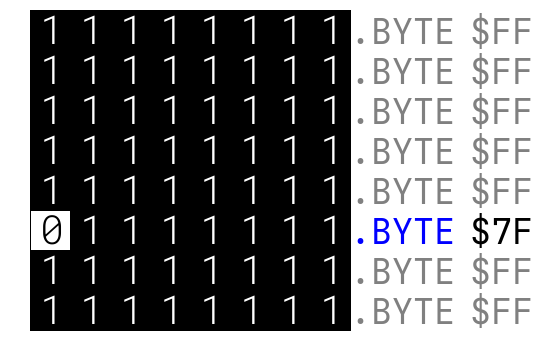

In [114]:
from PIL import ImageDraw, ImageFont

level = 1
level_name = level_names[level]
charset_ref = level_charsets[level]
character_set = character_sets[charset_ref]
for i,ba in enumerate(star_offsets_bits):
    bit_array = character_set['42'].copy()
    bit_array[5] = ba
    character_image = paintMonochromeCharacterDiagram(bit_array)
    before_bytes = '\n'.join(["$"+convertCharBitmapToByte(x) for x in bit_array[:5]])
    updated_byte = '\n'.join(["$"+convertCharBitmapToByte(x) for x in bit_array[5:6]])
    after_bytes = '\n'.join(["$"+convertCharBitmapToByte(x) for x in bit_array[6:]])
    img = generateBasicCharacterDiagram(character_image, before_bytes, updated_byte, after_bytes)
    img.save(f"starfield/BASIC_SMALL_STAR_{i}.png")
img

In [115]:
byte_literal = """.BYTE
"""


def generateBasicCharacterDiagram(character_image, before_bytes, updated_byte, after_bytes):

    img = Image.new('RGBA', (540,350))
    draw = ImageDraw.Draw(img)
    draw.rectangle([(0,0),img.size], fill = "white")

    # Sprite byte literals
    label_text = byte_literal * 2
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(before_bytes.split()) * (label_fnt_size + 5)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="grey")
    label = txt
    img.paste(label, (350,8))

    label_text = byte_literal * 2
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(updated_byte.split()) * (label_fnt_size + 5)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="blue")
    label = txt
    img.paste(label, (350,88))

    label_text = byte_literal * 4
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(after_bytes.split()) * (label_fnt_size + 5)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="grey")
    label = txt
    img.paste(label, (350,168))

    # Sprite bytes
    label_text = before_bytes
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(label_text.split()) * (label_fnt_size + 5)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="grey")
    label = txt
    img.paste(label, (470,8))

    label_text = updated_byte
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(label_text.split()) * (label_fnt_size + 5)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt
    img.paste(label, (470,88))

    label_text = after_bytes
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(label_text.split()) * (label_fnt_size + 5)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="grey")
    label = txt
    img.paste(label, (470,168))
    
    # Main Sprite image
    #character_image = character_image.resize((character_image.width * 2, character_image.height * 2), Image.NEAREST)
    img.paste(character_image, (30,10))

    return img

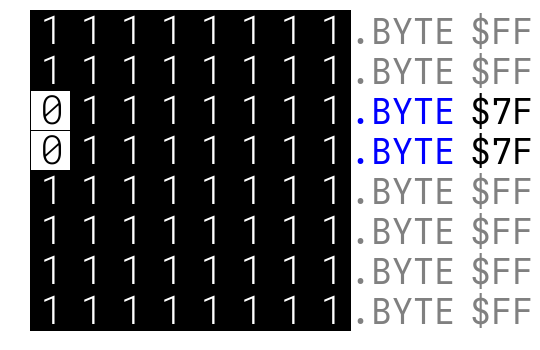

In [116]:
from PIL import ImageDraw, ImageFont

level = 1
level_name = level_names[level]
charset_ref = level_charsets[level]
character_set = character_sets[charset_ref]
for i,ba in enumerate(star_offsets_bits):
    bit_array = character_set['43'].copy()
    bit_array[2] = ba
    bit_array[3] = ba
    character_image = paintMonochromeCharacterDiagram(bit_array)
    before_bytes = '\n'.join(["$"+convertCharBitmapToByte(x) for x in bit_array[:2]])
    updated_byte = '\n'.join(["$"+convertCharBitmapToByte(x) for x in bit_array[2:4]])
    after_bytes = '\n'.join(["$"+convertCharBitmapToByte(x) for x in bit_array[4:8]])
    img = generateBasicCharacterDiagram(character_image, before_bytes, updated_byte, after_bytes)
    img.save(f"starfield/BASIC_BIG_STAR_{i}.png")
img

### Get the Manta Sprite

In [117]:
from PIL import Image

FACTOR = 15

def get_surface_snippet(level=1, x_offset=600, y_offset = 0, width=1000, height = 200):
    img = Image.open(f"bullets_player/surface_diagrams/{level}_no_text.png")
    img = img.crop((x_offset, y_offset, x_offset + width, y_offset + height))
    #img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)
    return img

def get_surface_character_snippet(level=1, x_offset=600, y_offset = 0, width=1000, height = 200):
    img = Image.open(f"surface_character_set_diagrams/surface_diagrams/{level}.png")
    img = img.crop((x_offset, y_offset, x_offset + width, y_offset + height))
    #img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)
    return img

def make_shadow(img, color=(0x4a, 0x4a, 0x4a, 255)):
    d = img.getdata()
    new_image = []
    for item in d:
        if item[3] == 0:
            new_image.append(item)
        else:
            new_image.append(color)
    # update image data
    img.putdata(new_image)
    return img

resize = lambda img,factor: img.resize((int(img.width * factor), int(img.height * factor)), Image.NEAREST)
add_offset = lambda a,b : [sum(x) for x in zip(a,b)]
scale = lambda x: x * FACTOR
cells = lambda x: x * 120

In [118]:
from PIL import Image, ImageDraw

c64_to_rgb = {
"c64_black": "#000000",     
"c64_white": "#ffffff",     
"c64_red": "#813338",       
"c64_cyan":  "#75cec8",     
"c64_purple": "#8e3c97",    
"c64_green": "#56ac4d",     
"c64_blue":  "#2e2c9b",     
"c64_yellow":  "#edf171",   
"c64_orange":  "#8e5029",   
"c64_brown": "#553800",     
"c64_ltred": "#c46c71",  
"c64_gray1":  "#4a4a4a",    
"c64_lightgray": "#7b7b7b", 
"c64_ltgreen": "#a9ff9f",
"c64_ltblue":  "#706deb",
"c64_gray3": "#b2b2b2",                             
}
img = Image.open("manta_spin_diagrams/MANTA1.png")
img = resize(img, FACTOR)
manta = img.copy()
shadow = make_shadow(img)

### Get the Stars


In [119]:
small_star = Image.open("surface_characters/1_42.png")
big_star = Image.open("surface_characters/1_43.png")

### Draw The Star Background 

In [120]:
!mkdir starfield

mkdir: cannot create directory ‘starfield’: File exists


In [121]:
c64_to_rgb = {
"c64_black": "#000000",     
"c64_white": "#ffffff",     
"c64_red": "#813338",       
"c64_cyan":  "#75cec8",     
"c64_purple": "#8e3c97",    
"c64_green": "#56ac4d",     
"c64_blue":  "#2e2c9b",     
"c64_yellow":  "#edf171",   
"c64_orange":  "#8e5029",   
"c64_brown": "#553800",     
"c64_ltred": "#c46c71",  
"c64_gray1":  "#4a4a4a",    
"c64_lightgray": "#7b7b7b", 
"c64_ltgreen": "#a9ff9f",
"c64_ltblue":  "#706deb",
"c64_gray3": "#b2b2b2",                             
}

In [122]:
16*8

128

In [123]:
import random
def addStarsToRow(background, row):
    for x in range(0,38):
        r = random.randint(0,255)
        if r < 240:
            continue
        if r < 248:
            background.paste(small_star, (cells(x), cells(row)), mask=small_star)
            continue
        background.paste(big_star, (cells(x), cells(row)), mask=big_star)
    return background

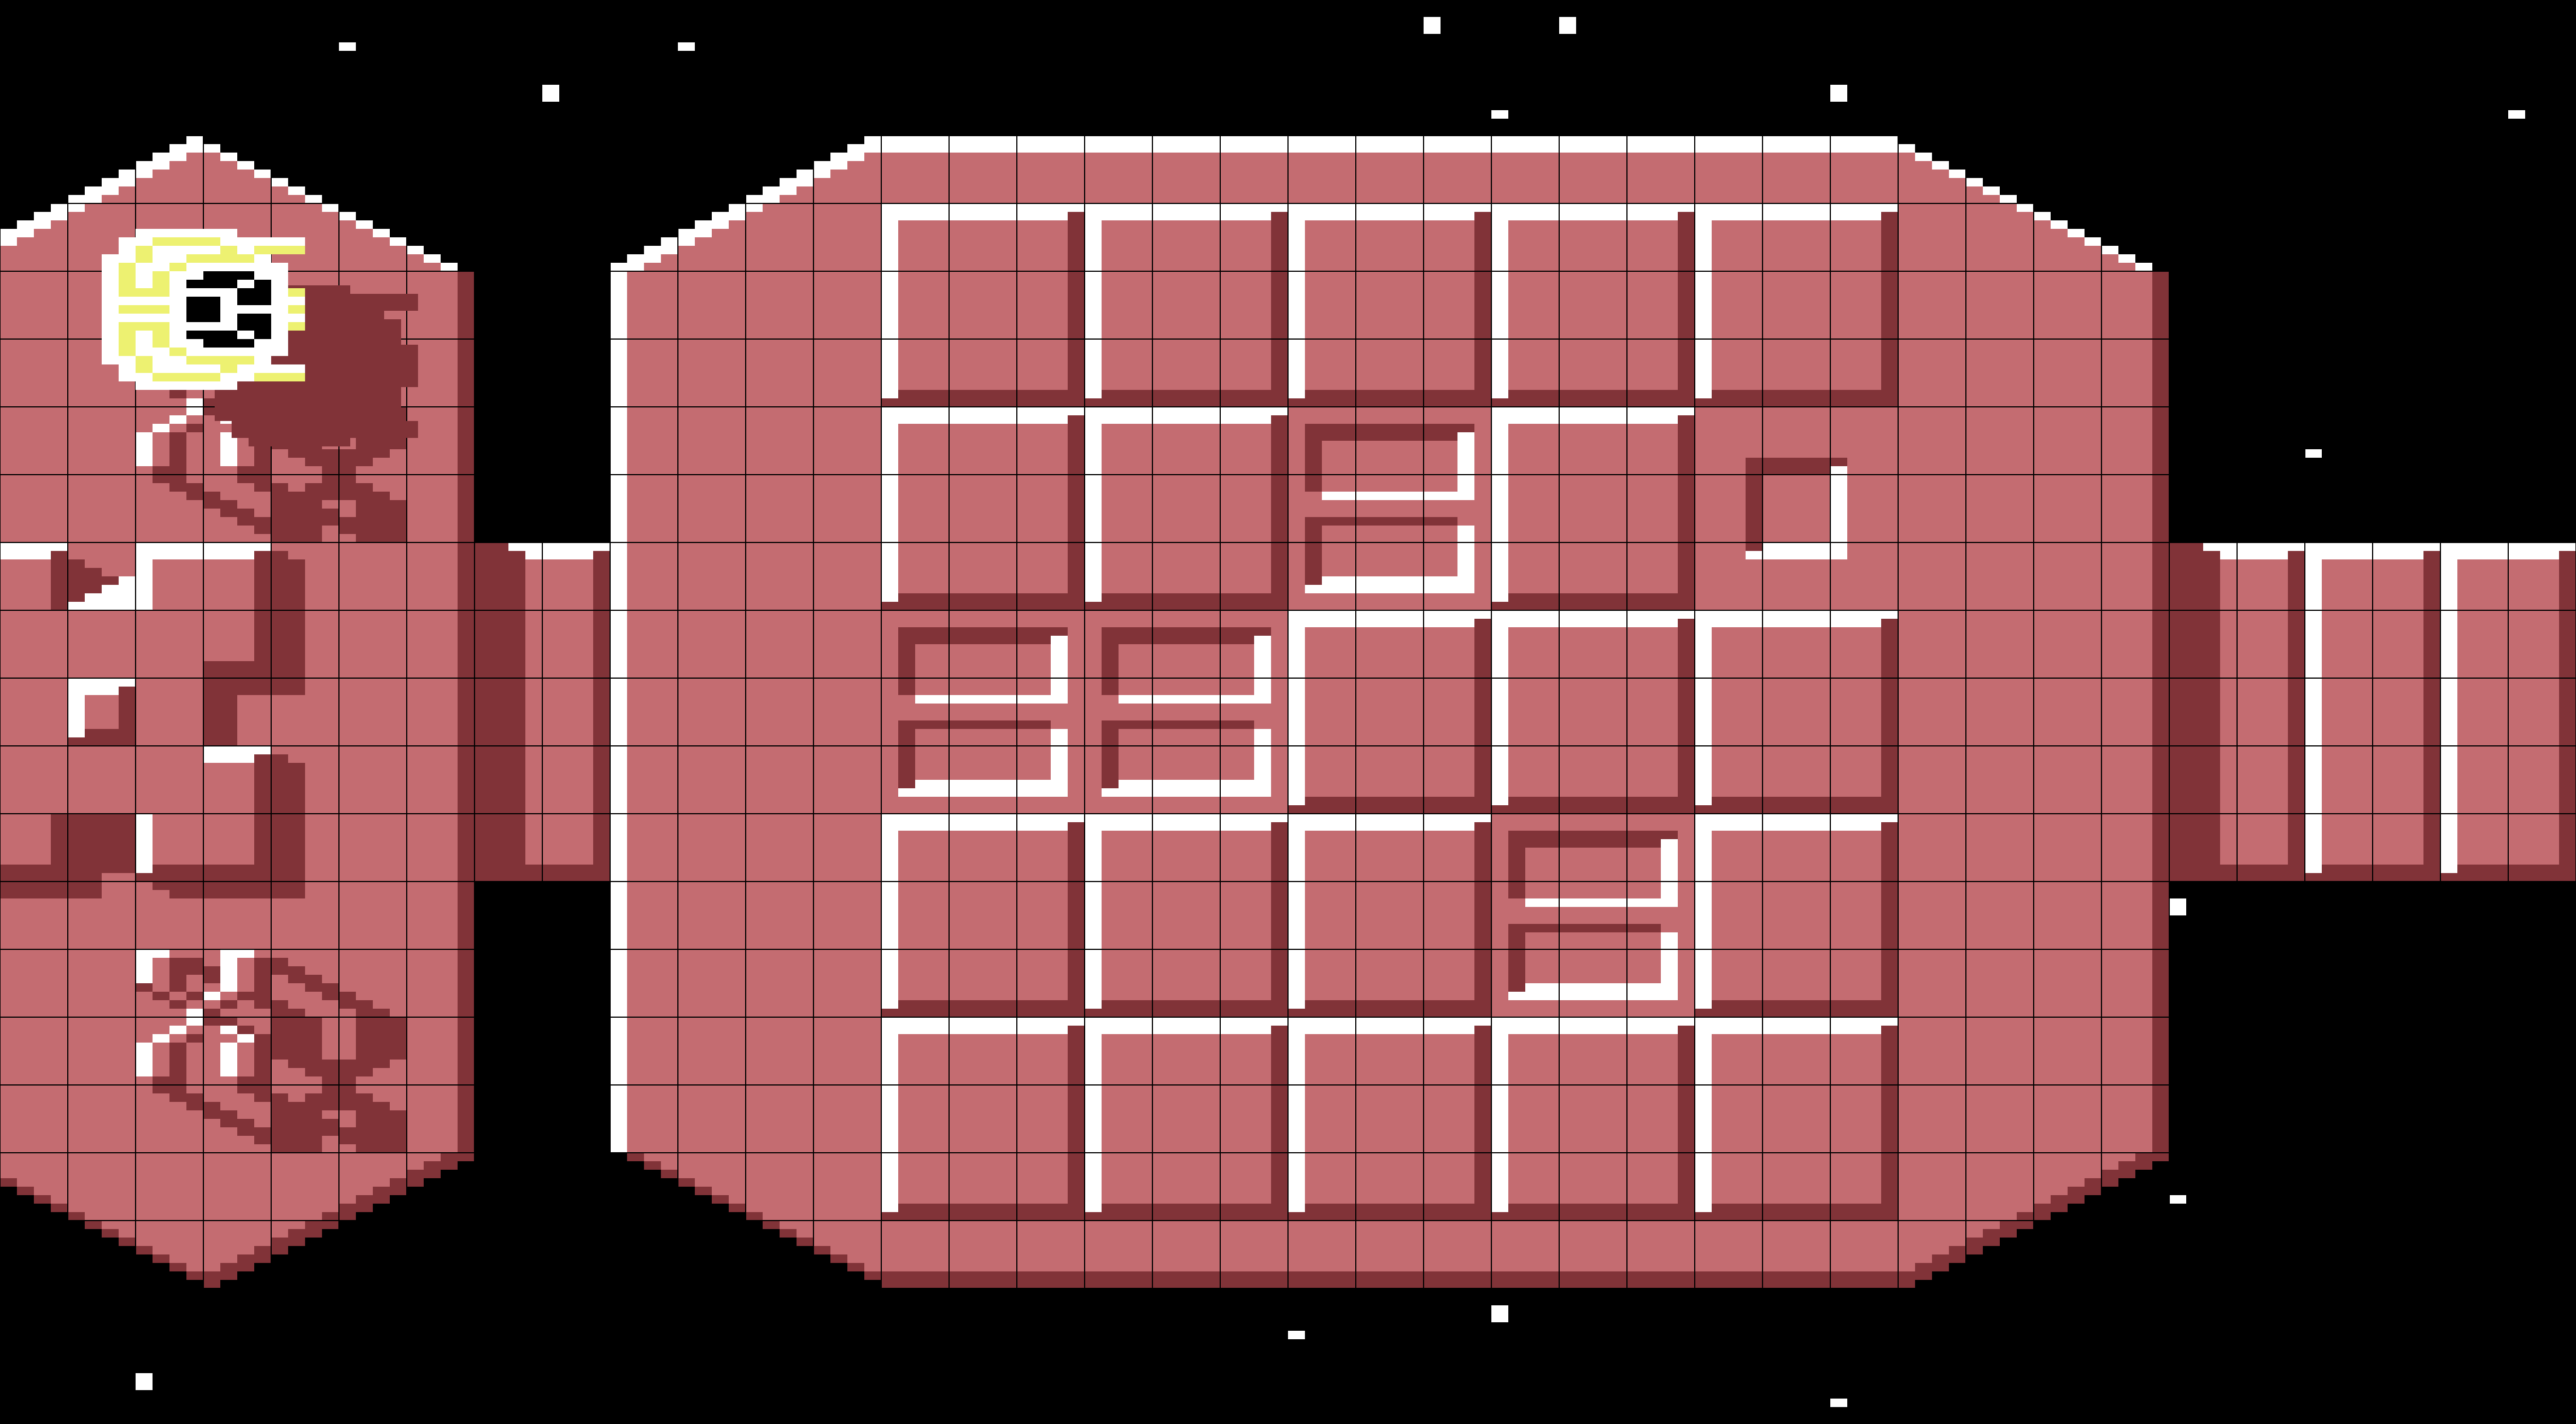

In [124]:
level = 15

background = Image.new('RGBA', (cells(38), cells(21)), color="black")

rows = [0,1,19,20,6,8,10,13,15,17,18]
for row in rows:
    background = addStarsToRow(background, row)

diagram = get_surface_snippet(level=level, x_offset=cells(65), y_offset = cells(0), width=cells(38), height = cells(17))
shadow = make_shadow(manta.copy(), color=(0x81,0x33,0x38,255))
manta_pos = (scale(12),scale(10))
shadow_offset = (20*10,10*10)
diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
diagram.paste(manta, manta_pos, mask=manta)

"""
bullet_x = cells(8)
bullet_pos = (bullet_x, scale(10) + 30)
diagram.paste(bullet, bullet_pos, mask=bullet)
bullet_pos = (bullet_x, scale(25) + 30)
diagram.paste(bullet, bullet_pos, mask=bullet)
"""

background.paste(diagram, (0,cells(2)), mask=diagram)
background.save(f"starfield/dreadnought_with_stars.png")
background

### Top Stars

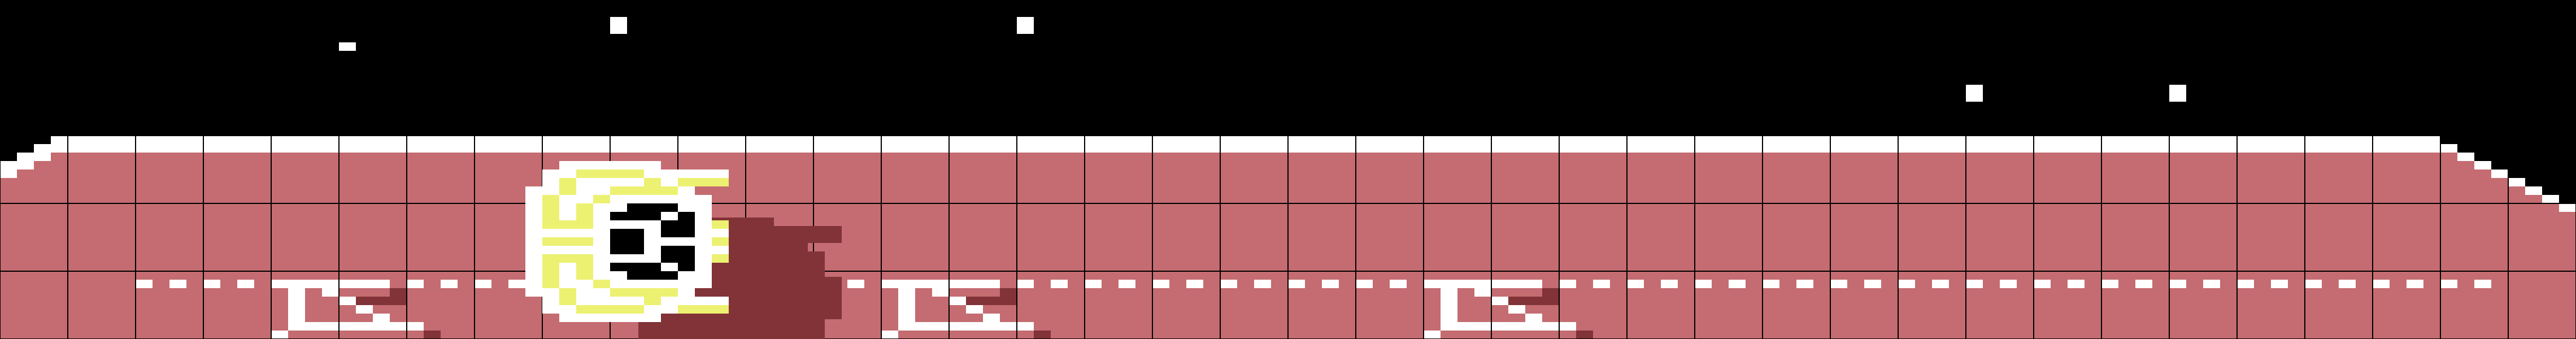

In [125]:
level = 15

background = Image.new('RGBA', (cells(38), cells(5)), color="black")

rows = [0,1,19,20,6,8,10,13,15,17,18]
for row in rows:
    background = addStarsToRow(background, row)

diagram = get_surface_snippet(level=level, x_offset=cells(110), y_offset = cells(0), width=cells(38), height = cells(3))
shadow = make_shadow(manta.copy(), color=(0x81,0x33,0x38,255))
manta_pos = (scale(62),scale(2))
shadow_offset = (20*10,10*10)
diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
diagram.paste(manta, manta_pos, mask=manta)

background.paste(diagram, (0,cells(2)), mask=diagram)
background.save(f"starfield/dreadnought_with_stars_top.png")
background

### Bottom Stars

In [126]:
def make_mask(i):
    img = i.copy()
    d = img.getdata()
    new_image = []
    for item in d:
        if item[3] != 0:
            new_image.append((0xff, 0xff, 0xff))
        else:
            new_image.append((0,0,0))
    # update image data
    img.putdata(new_image)
    return img


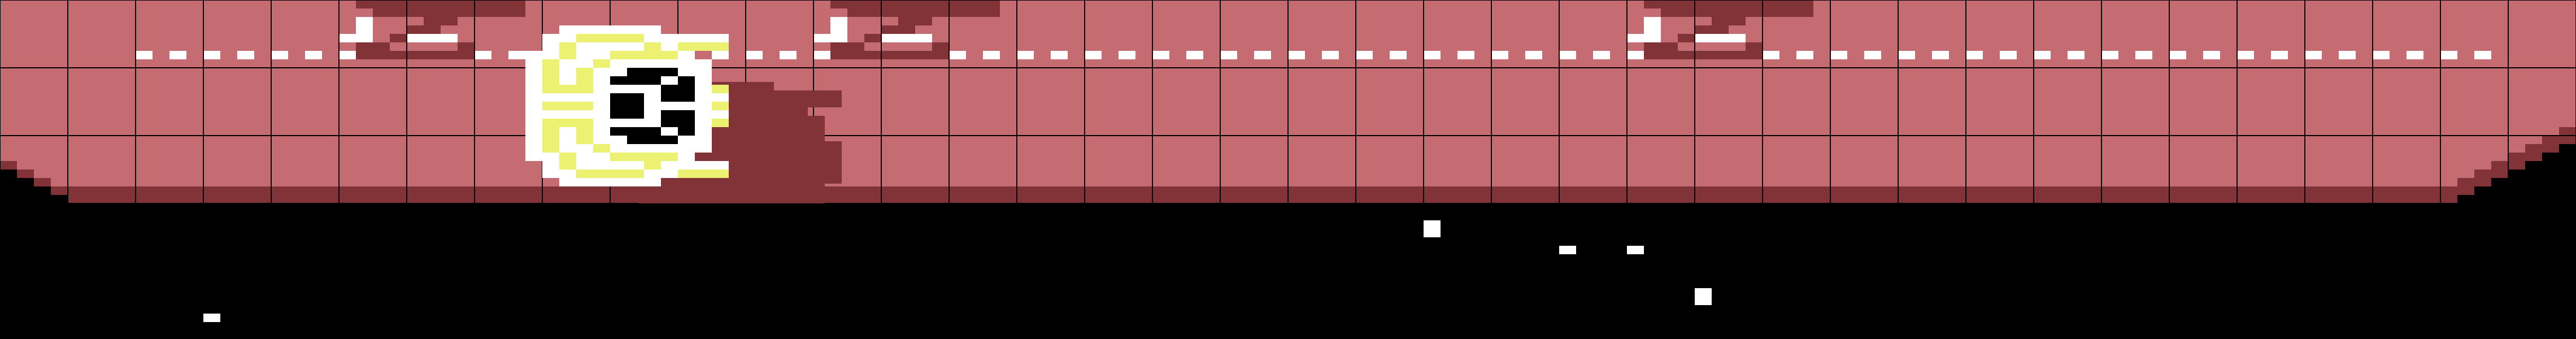

In [127]:
level = 15

background = Image.new('RGBA', (cells(38), cells(5)), color="black")

rows = [3,4]
for row in rows:
    background = addStarsToRow(background, row)

diagram = get_surface_snippet(level=level, x_offset=cells(110), y_offset = cells(14), width=cells(38), height = cells(4))
mask = make_mask(diagram).convert('L')

shadow = make_shadow(manta.copy(), color=(0x81,0x33,0x38,255))
manta_pos = (scale(62),scale(2))
shadow_offset = (20*10,10*10)
diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
diagram.putalpha(mask)
diagram.paste(manta, manta_pos, mask=manta)

background.paste(diagram, (0,cells(0)), mask=diagram)
background.save(f"starfield/dreadnought_with_stars_bottom.png")
background

In [128]:
0x14

20

### Just the background

In [129]:
import random
def addRandomStar(background):
    rx = random.randint(0,31)
    if rx < 20:
        rx+=4
    ry = random.randint(7,22)
    rs = random.randint(0,1)
    background.paste(small_star if rs else big_star, (cells(rx), cells(ry)), mask=small_star if rs else big_star)
    return background

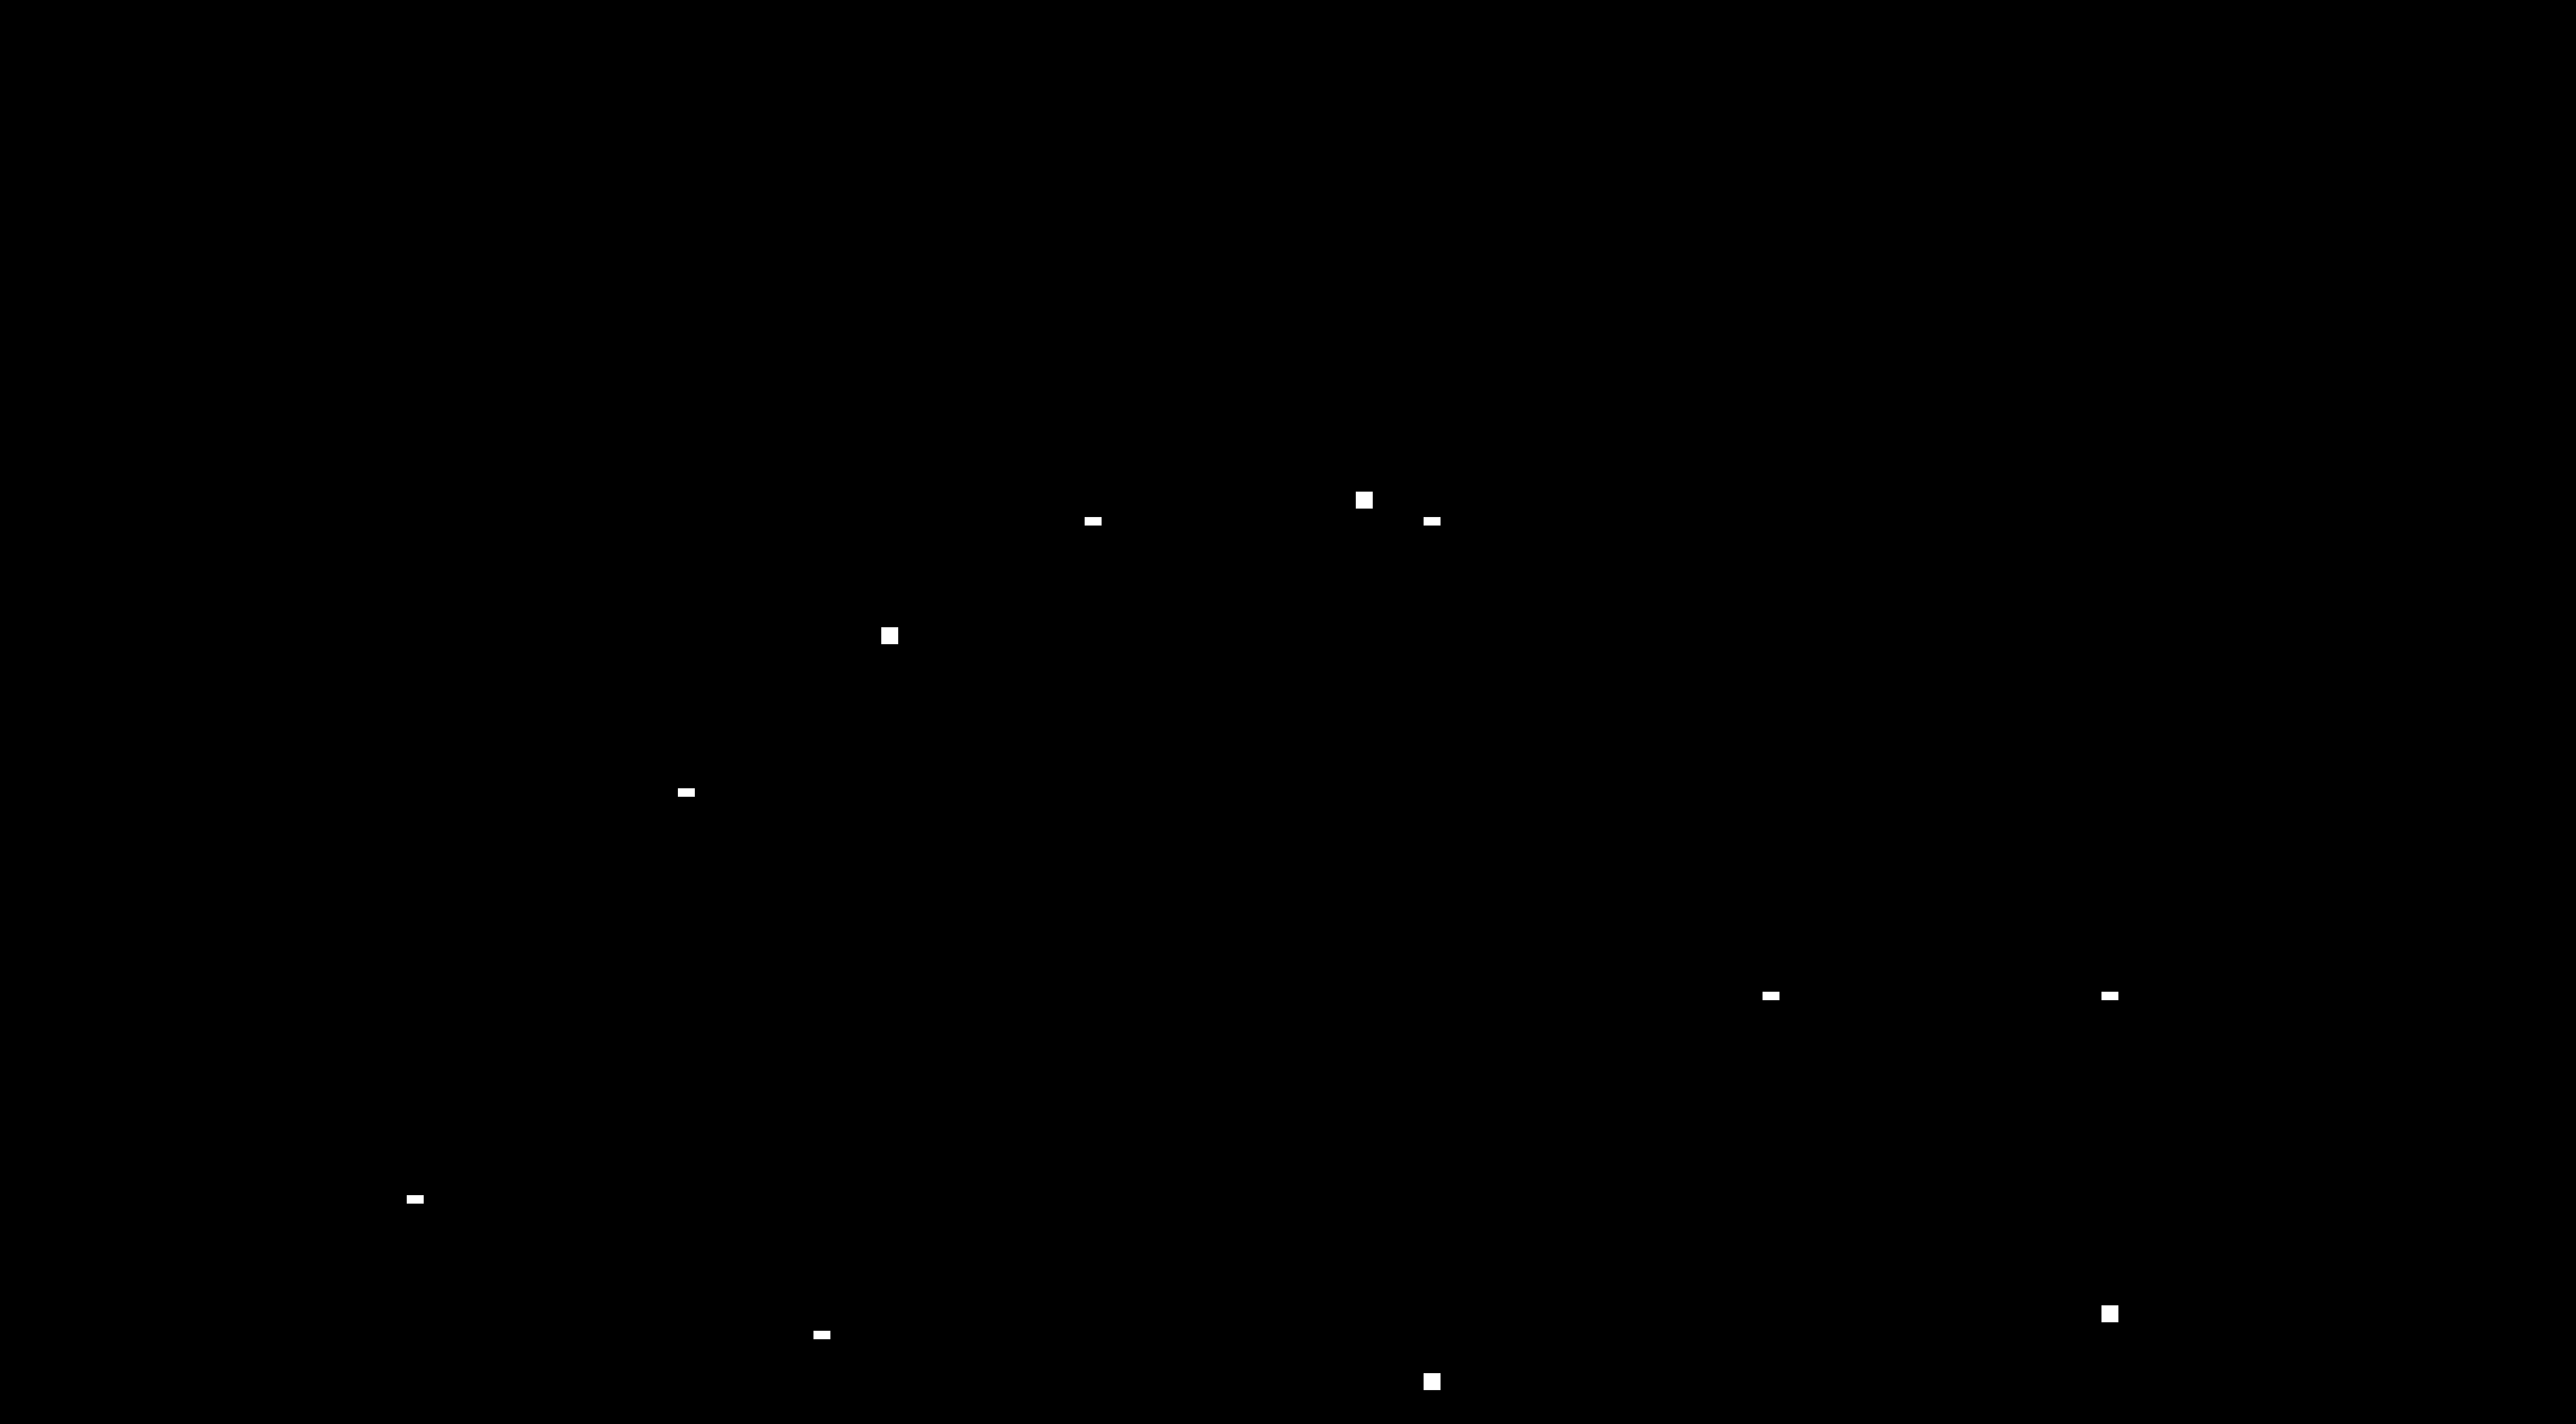

In [130]:
background = Image.new('RGBA', (cells(38), cells(21)), color="black")
for i in range(0,16):
    background = addRandomStar(background)
background.save(f"starfield/background_stars_2.png")
background

### Full Star Background Rendering

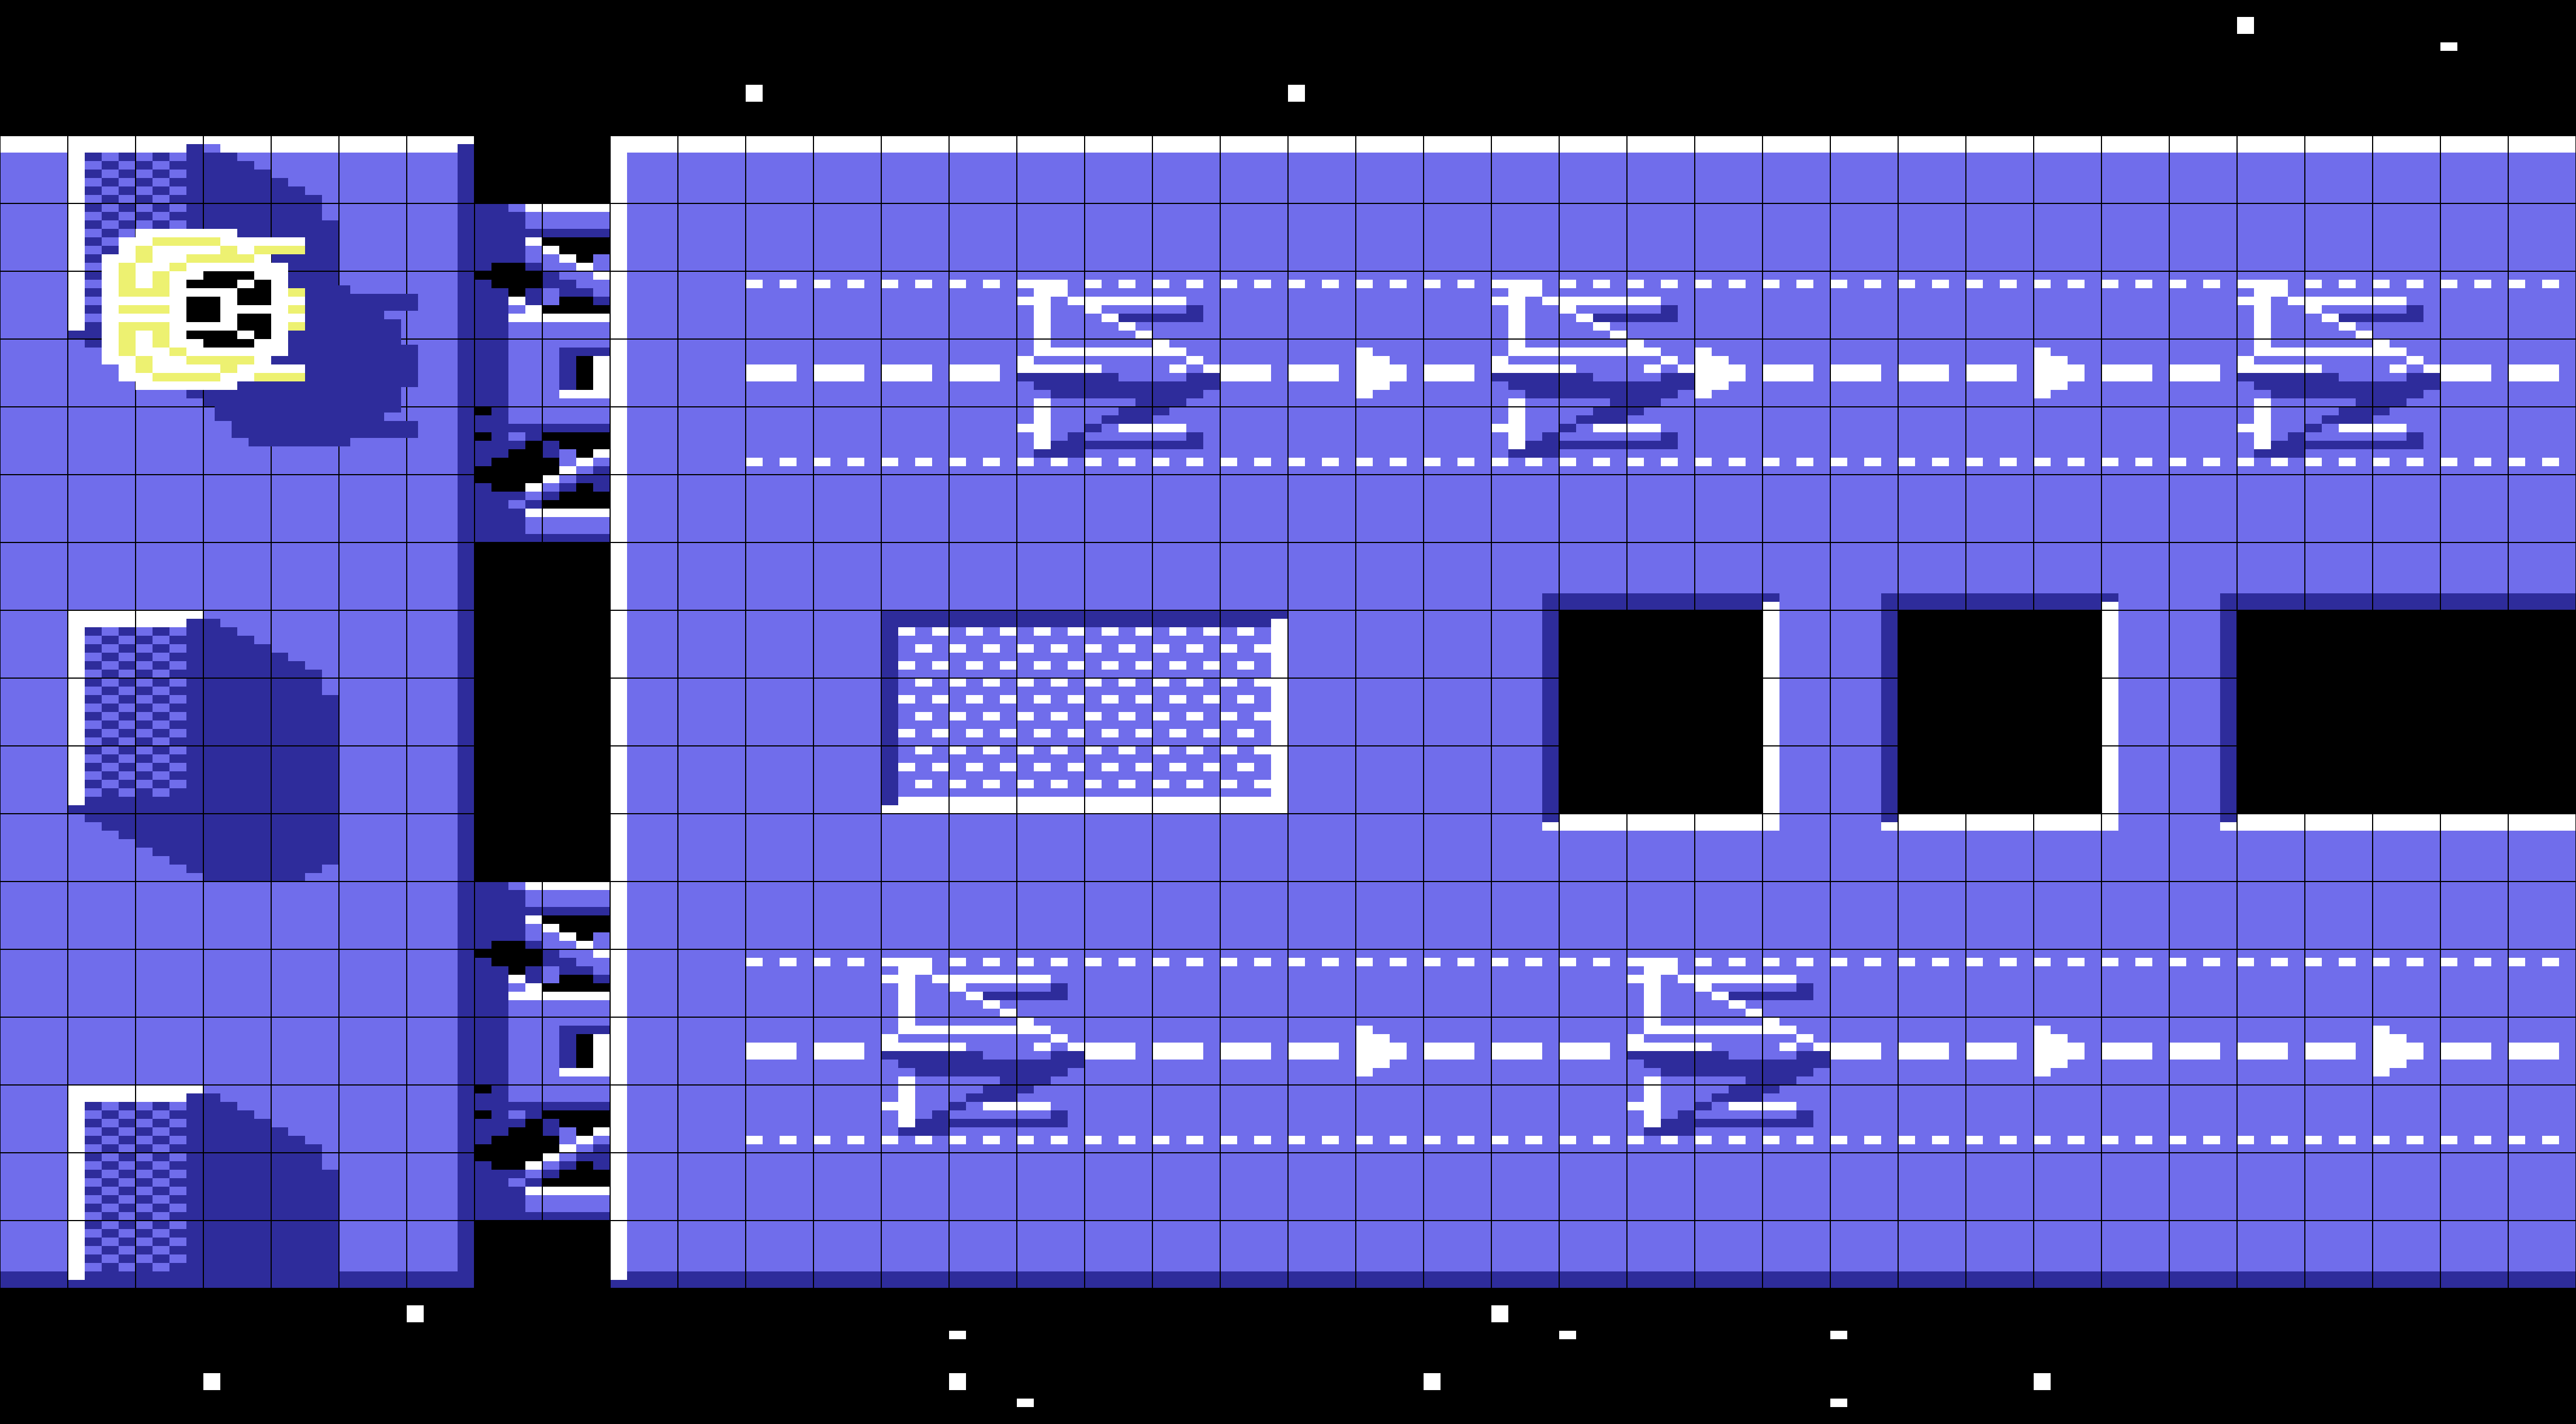

In [131]:
background = Image.new('RGBA', (cells(38), cells(21)), color="black")
for i in range(0,16):
    background = addRandomStar(background)

rows = [0,1,19,20]
for row in rows:
    background = addStarsToRow(background, row)

level = 14
diagram = get_surface_snippet(level=level, x_offset=cells(165), y_offset = cells(0), width=cells(38), height = cells(17))
shadow = make_shadow(manta.copy(), color=(0x2e,0x2c,0x9b,255))
manta_pos = (scale(12),scale(10))
shadow_offset = (20*10,10*10)
diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
diagram.paste(manta, manta_pos, mask=manta)

background.paste(diagram, (0,cells(2)), mask=diagram)
background.save(f"starfield/dreadnought_with_stars_full.png")
background

### Show how the star moves with the dreadhnought during scrolling if we do nothing

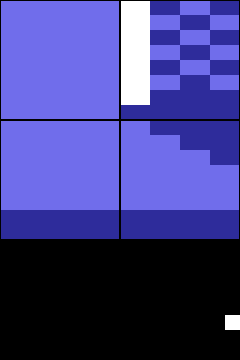

In [144]:
level = 14
diagram = get_surface_snippet(level=level, x_offset=cells(160), y_offset = cells(15), width=cells(4), height = cells(3))

star_x = -120

for i in range(0,9):
    background = Image.new('RGBA', (cells(2), cells(3)), color="black")
    background.paste(diagram, (star_x,0), mask=diagram)
    star = Image.open("starfield/42_0.png")
    background.paste(star, (star_x+120, cells(2)), mask=star)
    star_x +=15
    background.save(f"starfield/star_moving_with_dreadnought{i}.png")
background

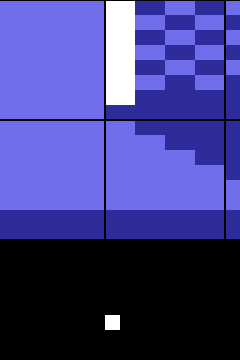

In [145]:
level = 14
diagram = get_surface_snippet(level=level, x_offset=cells(160), y_offset = cells(15), width=cells(4), height = cells(3))

star_x = -120

for i in range(0,8):
    background = Image.new('RGBA', (cells(2), cells(3)), color="black")
    background.paste(diagram, (star_x,0), mask=diagram)
    star = Image.open("starfield/42_0.png")
    background.paste(star, (0, cells(2)), mask=star)
    star_x +=15
    background.save(f"starfield/star_not_moving_with_dreadnought{i}.png")
background

### Single Block diagram showing how the star stays in the same position

In [143]:
level = 14
diagram = get_surface_snippet(level=level, x_offset=cells(160), y_offset = cells(15), width=cells(4), height = cells(2))
diagram = resize(diagram,2.66)

for i in range(1,8):
    star_x = -320
    background = Image.new('RGBA', (cells(1), cells(3)), color="black")
    background = resize(background,2.66)
    background.paste(diagram, (star_x,0), mask=diagram)
    star = Image.open(f"starfield/42_{i}_raw.png")
    background.paste(star, (0, 640), mask=star)
    background.save(f"starfield/not_moving_with_dreadnought{i}_before.png")

    star_x += 40*i

    background = Image.new('RGBA', (cells(1), cells(3)), color="black")
    background = resize(background,2.66)
    background.paste(diagram, (star_x,0), mask=diagram)
    star = Image.open("starfield/42_0_raw.png")
    background.paste(star, (0, 640), mask=star)
    background.save(f"starfield/not_moving_with_dreadnought{i}_after.png")


## Scratchpad